# Phân tích dữ liệu và các yếu tố tác động đến giá nhà trọ
## 1. Phát biểu bài toán 
- Mục tiêu của bài toán là Khảo sát dữ liệu về phòng trọ sinh viên tại 3 thành phố Đà Nẵng, Hà Nội và Hồ Chí Minh nhằm xác định các đặc trưng quan trọng ảnh hưởng đến giá thuê phòng trọ. Từ đó, đánh giá tính khả thi cho việc xây dựng mô hình dự đoán với biến mục tiêu (target variable) $Y$ là Giá cho thuê từ các biến/đặc trưng $X_i$ (Diện tích, vị trí, tiện ích).
- Loại bài toán mô hinh hóa: Do biến mục tiêu $Y$ (Giá cho thuê) đã được xác định cụ thể và là một biến số thực (liên tục), nên việc mô hình hóa ở tương lại sẽ là bài toán Hồi quy (Regression).
- Tính khả thi: Dữ liệu có tính khả thi khá cao vì có sự tương quan tuyến tính/phi tuyến rõ rệt (Diện tích tỷ lệ thuận với giá, Tiện ích càng nhiều thì giá càng cao).
- Tập đặc trưng hữu ích ($X_i$) đề xuất `Diện tích`, `Thành phố`, `Quận/Huyện`, và Các tiện ích (Máy lạnh, Thang máy, Giờ tự do,...).

## 2. Thu thập dữ liệu
- Nguồn dữ liệu: Dữ liệu được crawl từ trang web đăng tin nhà trọ tại phongtro123.com
- Số lượng mẫu: 2655 mẫu (mỗi thành phố cào 50 trang dữ liệu).
- Số lượng biến: 
    + Mã tin: Mã tin đăng (ID duy nhất cho mỗi tin đăng).
    + Thời gian đăng: Thời gian tin đăng được đăng tải.
    + Thành phố: Thành phố nơi phòng trọ được đăng.
    + Quận/Huyện: Quận hoặc huyện nơi phòng trọ được đăng.
    + Giá cho thuê: Giá thuê phòng trọ (đơn vị: triệu đồng/tháng).
    + Diện tích: Diện tích phòng trọ (đơn vị: m²).
    + Đầy đủ nội thất: Biến nhị phân (1 nếu phòng trọ có đầy đủ nội thất, 0 nếu không).
    + Có gác lửng: Biến nhị phân (1 nếu phòng trọ có gác lửng, 0 nếu không).
    + Máy lạnh: Biến nhị phân (1 nếu phòng trọ có máy lạnh, 0 nếu không).
    + Nóng lạnh: Biến nhị phân (1 nếu phòng trọ có nước nóng lạnh, 0 nếu không).
    + Thang máy: Biến nhị phân (1 nếu phòng trọ có thang máy, 0 nếu không).
    + Tủ lạnh: Biến nhị phân (1 nếu phòng trọ có tủ lạnh, 0 nếu không).
    + Máy giặt: Biến nhị phân (1 nếu phòng trọ có máy giặt, 0 nếu không).
    + Giờ tự do: Biến nhị phân (1 nếu phòng trọ có giờ tự do, 0 nếu không).
    + Bảo vệ an ninh: Biến nhị phân (1 nếu phòng trọ có bảo vệ an ninh, 0 nếu không).
    + Không chung chủ: Biến nhị phân (1 nếu phòng trọ không chung chủ, 0 nếu có chung chủ).
    + Tiêu đề: Tiêu đề tin đăng.
    + Điện thoại: Số điện thoại liên hệ.
    + Địa chỉ chi tiết: Địa chỉ chi tiết của phòng trọ.

### Cách thức thu thập
- Mô tả thu thập: Dữ liệu tự thu thập (crawl) bằng cách sử dụng kỹ thuật web scraping từ trang web phongtro123.com, nơi có nhiều tin đăng về phòng trọ sinh viên tại các thành phố lớn. Để vượt qua cơ chế chống bot (tường lửa Cloudflare) của trang web, nhóm đã sử dụng thư viện `cloudscraper` kết hợp với `BeautifulSoup` trong Python. Thông tin được bóc tách trực tiếp từ cấu trúc `JSON-LD` nhúng trong mã nguồn HTML, đảm bảo tính chính xác tuyệt đối. Dữ liệu sau đó được lưu trữ vào file CSV.


In [ ]:
import cloudscraper
from bs4 import BeautifulSoup
import re
import time
import random
import pandas as pd
import json
import os

# 1. CẤU HÌNH VƯỢT TƯỜNG LỬA
scraper = cloudscraper.create_scraper(
    browser={'browser': 'chrome', 'platform': 'windows', 'mobile': False}
)
    
DANH_MUC = [
    {"Thành_Phố": "Đà Nẵng", "URL": "https://phongtro123.com/tinh-thanh/da-nang"},
    {"Thành_Phố": "Hồ Chí Minh", "URL": "https://phongtro123.com/tinh-thanh/ho-chi-minh"},
    {"Thành_Phố": "Hà Nội", "URL": "https://phongtro123.com/tinh-thanh/ha-noi"}
]

MAX_PAGES = 50 
FILE_NAME = 'raw_data.csv'

all_rooms = []
seen_urls = set() 
df_old = None

# 1.5. HỆ THỐNG KHÔI PHỤC TIẾN TRÌNH (RESUME)
if os.path.exists(FILE_NAME):
    print(f"[*] Phát hiện file dữ liệu cũ '{FILE_NAME}'. Đang nạp dữ liệu để cào tiếp...")
    try:
        df_old = pd.read_csv(FILE_NAME)
        all_rooms = df_old.to_dict('records')
        # Bổ sung key URL tạm để chống trùng, nếu file CSV cũ không lưu URL
        # Nếu CSV cũ đã xóa URL, đoạn này sẽ chỉ lấy các tiêu đề hoặc ID để set
        print(f"[*] Đã khôi phục thành công {len(all_rooms)} phòng cũ!")
    except Exception as e:
        print(f"[!] Lỗi khi đọc file cũ: {e}")

# 2. HÀM FEATURE ENGINEERING
def extract_utilities(text_content):
    d = str(text_content).lower()
    return {
        "Máy_Lạnh": 1 if re.search(r'(máy lạnh|điều hòa|điều hoà)', d) else 0,
        "Nóng_Lạnh": 1 if re.search(r'(nóng lạnh|máy nước nóng|bình nước nóng)', d) else 0,
        "Thang_Máy": 1 if re.search(r'(thang máy)', d) else 0,
        "Tủ_Lạnh": 1 if re.search(r'(tủ lạnh)', d) else 0,
        "Máy_Giặt": 1 if re.search(r'(máy giặt)', d) else 0,
        "Đầy_Đủ_Nội_Thất": 1 if re.search(r'(đầy đủ nội thất|full nội thất|nội thất đầy đủ)', d) else 0,
        "Có_Gác_Lửng": 1 if re.search(r'(có gác|gác lửng|gác xép)', d) else 0,
        "Bảo_Vệ_An_Ninh": 1 if re.search(r'(bảo vệ|an ninh|camera)', d) else 0,
        "Giờ_Tự_Do": 1 if re.search(r'(giờ giấc tự do|giờ tự do|chìa khóa trao tay)', d) else 0,
        "Không_Chung_Chủ": 1 if re.search(r'(không chung chủ|lối đi riêng)', d) else 0
    }

def extract_price(price_str):
    if not price_str: return None
    p = str(price_str).lower().replace(",", ".")
    match = re.search(r'(\d+(?:\.\d+)?)', p)
    if not match: return None
    val = float(match.group(1))
    
    if 'triệu' in p: return val
    if 'đồng' in p or 'vnđ' in p: return val / 1000000
    if 'k' in p: return val / 1000
    return val

# 3. QUÁ TRÌNH CÀO
try:
    for dm in DANH_MUC:
        thanh_pho = dm["Thành_Phố"]
        
        start_page = 1
        if df_old is not None and thanh_pho in df_old['Thành_Phố'].values:
            so_luong_da_cao = len(df_old[df_old['Thành_Phố'] == thanh_pho])
            start_page = (so_luong_da_cao // 20) + 1 
            print(f"\n👉 ĐANG QUÉT: {thanh_pho.upper()} (Chạy tiếp từ Trang {start_page})")
        else:
            print(f"\n👉 ĐANG QUÉT: {thanh_pho.upper()} (Bắt đầu từ Trang 1)")
            
        if start_page > MAX_PAGES:
            print(f"    -> Đã cào đủ {MAX_PAGES} trang cho {thanh_pho}. Bỏ qua!")
            continue
        
        for page in range(start_page, MAX_PAGES + 1):
            list_url = f"{dm['URL']}?page={page}" if page > 1 else dm['URL']
            print(f"  + Trang {page} / {MAX_PAGES}...")
            
            try:
                res = scraper.get(list_url, timeout=15)
                if res.status_code != 200: continue
                
                soup = BeautifulSoup(res.text, "html.parser")
                scripts = soup.find_all('script', type='application/ld+json')
                
                json_rooms = []
                has_new_room = False 
                
                for script in scripts:
                    try:
                        raw_json = script.string.strip() if script.string else ""
                        if not raw_json: continue
                        json_data = json.loads(raw_json)
                        
                        if isinstance(json_data, dict) and json_data.get('@type') in ['Hostel', 'Apartment']:
                            url_val = json_data.get('url', '')
                            if not url_val: continue
                            
                            # Dùng Mã_Tin (ID) để kiểm tra trùng thay vì URL, vì file CSV cũ đã bị cắt URL
                            code_match = re.search(r'-pr(\d+)\.html', url_val)
                            ma_tin_val = code_match.group(1) if code_match else None
                            
                            if ma_tin_val and ma_tin_val not in seen_urls:
                                seen_urls.add(ma_tin_val)
                                has_new_room = True 
                                
                                room = {
                                    "Mã_Tin": ma_tin_val,
                                    "URL": url_val,
                                    "Thành_Phố": thanh_pho,
                                    "Tiêu_Đề": json_data.get('name'),
                                    "Điện_Thoại": json_data.get('telephone'),
                                    "Mô_Tả_Tạm": json_data.get('description', '') 
                                }
                                
                                if 'floorSize' in json_data and isinstance(json_data['floorSize'], dict):
                                    room["Diện_Tích_m2"] = float(json_data['floorSize'].get('value', 0))
                                    
                                if 'priceRange' in json_data:
                                    room["Giá_Cho_Thuê"] = int(json_data.get('priceRange', 0)) / 1000000
                                    
                                address_obj = json_data.get('address', {})
                                if isinstance(address_obj, dict):
                                    full_address = address_obj.get('streetAddress', '')
                                    room["Địa_Chỉ_Chi_Tiết"] = full_address
                                    qh_match = re.search(r'(?:Quận|Huyện)\s+([^,]+)', full_address, re.IGNORECASE)
                                    room["Quận_Huyện"] = qh_match.group(1).strip() if qh_match else "Không rõ"
                                        
                                json_rooms.append(room)
                    except Exception:
                        continue
                
                if not has_new_room:
                    print(f"    -> [!] Đã quét hết tin mới tại {thanh_pho}. Chuyển thành phố khác!")
                    break
                    
                print(f"    -> Đã lấy sơ bộ {len(json_rooms)} phòng. Đang vào chi tiết...")
                
                found_rooms = 0
                for room in json_rooms:
                    try:
                        detail_res = scraper.get(room["URL"], timeout=15)
                        detail_soup = BeautifulSoup(detail_res.text, "html.parser")
                        
                        if "Giá_Cho_Thuê" not in room or pd.isna(room.get("Giá_Cho_Thuê")):
                            price_tag = detail_soup.select_one(".post-price, .item-price, .text-green")
                            if price_tag:
                                room["Giá_Cho_Thuê"] = extract_price(price_tag.text)
                                
                        if "Diện_Tích_m2" not in room or pd.isna(room.get("Diện_Tích_m2")):
                            for span in detail_soup.find_all('span'):
                                span_text = span.text.strip().lower()
                                if 'm2' in span_text or 'm²' in span_text:
                                    a_match = re.search(r'(\d+(?:\.\d+)?)\s*m', span_text)
                                    if a_match:
                                        room["Diện_Tích_m2"] = float(a_match.group(1))
                                        break 
                        
                        time_tag = detail_soup.find('time')
                        if time_tag and time_tag.has_attr('title'):
                            room["Thời_Gian_Đăng"] = time_tag['title'].replace("Cập nhật:", "").strip()
                        else:
                            room["Thời_Gian_Đăng"] = "Không rõ"
                        
                        desc_tag = detail_soup.select_one(".post-content, .section-content")
                        if desc_tag:
                            room["Mô_Tả_Tạm"] = desc_tag.text.strip().replace('\n', ' ')
                        
                        noi_bat_text = ""
                        noi_bat_items = detail_soup.select(".col-3 .text-body")
                        for item in noi_bat_items:
                            if 'opacity-75' not in item.get('class', []) and item.text:
                                noi_bat_text += item.text.strip() + " | "
                                
                        full_text = str(room.get("Tiêu_Đề","")) + " " + str(room.get("Mô_Tả_Tạm","")) + " " + noi_bat_text
                        
                        room.update(extract_utilities(full_text))
                        
                        all_rooms.append(room)
                        found_rooms += 1
                        
                        time.sleep(random.uniform(0.5, 1.5))
                        
                    except Exception as e:
                        continue
                        
                print(f"    -> Đã hoàn tất chi tiết {found_rooms} phòng.")
                
            except Exception as e:
                print(f"  [!] Lỗi kết nối trang: {e}")
                break

except KeyboardInterrupt:
    print("\n[!] ⛔ BẠN VỪA BẤM DỪNG (CTRL+C). Đang tiến hành lưu toàn bộ dữ liệu đã cào được...")

# 4. XUẤT DỮ LIỆU SẠCH (Đã bỏ cột Điện/Nước)
if all_rooms:
    df = pd.DataFrame(all_rooms)
    
    # Danh sách cột xuất file: BỎ Giá_Điện_VNĐ và Giá_Nước_VNĐ
    cols = ['Mã_Tin', 'Thời_Gian_Đăng', 'Thành_Phố', 'Quận_Huyện', 'Giá_Cho_Thuê', 'Diện_Tích_m2', 
            'Đầy_Đủ_Nội_Thất', 'Có_Gác_Lửng', 'Máy_Lạnh', 'Nóng_Lạnh', 'Thang_Máy', 
            'Tủ_Lạnh', 'Máy_Giặt', 'Bảo_Vệ_An_Ninh', 'Giờ_Tự_Do', 'Không_Chung_Chủ', 
            'Tiêu_Đề', 'Điện_Thoại', 'Địa_Chỉ_Chi_Tiết']
            
    df = df[[c for c in cols if c in df.columns]]
    df = df.dropna(subset=['Giá_Cho_Thuê', 'Diện_Tích_m2'])
    
    # Chống ghi trùng dòng (Lọc theo Mã_Tin)
    df = df.drop_duplicates(subset=['Mã_Tin'], keep='last')
    
    df.to_csv(FILE_NAME, index=False, encoding='utf-8-sig')
    print(f"\n🎉 XUẤT SẮC! Đã lưu an toàn {len(df)} phòng trọ vào file '{FILE_NAME}'")
else:
    print("\n[!] Chưa cào được dữ liệu nào.")

## 3. Thống kê mô tả dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

### Load raw data

In [2]:
plt.rcParams['font.family'] = 'sans-serif'
plt.style.use('ggplot')

# Load raw data
df_raw = pd.read_csv('../data_phongtro/crawl/raw_data.csv')

### Thống kê tổng quan về tập dữ liệu thô

In [3]:
print("THÔNG TIN TỔNG QUAN VỀ TẬP DỮ LIỆU THÔ")
print(f"Tổng số mẫu trong tập dữ liẹu: {df_raw.shape[0]} mẫu.")
print(f"Tổng số đặc trưng (cột) trong tập dữ liệu: {df_raw.shape[1]} biến.")

THÔNG TIN TỔNG QUAN VỀ TẬP DỮ LIỆU THÔ
Tổng số mẫu trong tập dữ liẹu: 2655 mẫu.
Tổng số đặc trưng (cột) trong tập dữ liệu: 19 biến.


### Xem trước 5 dòng của file raw_data

In [4]:
display(df_raw.head(5))

,Mã_Tin,Thời_Gian_Đăng,Thành_Phố,Quận_Huyện,Giá_Cho_Thuê,Diện_Tích_m2,Đầy_Đủ_Nội_Thất,Có_Gác_Lửng,Máy_Lạnh,Nóng_Lạnh,Thang_Máy,Tủ_Lạnh,Máy_Giặt,Bảo_Vệ_An_Ninh,Giờ_Tự_Do,Không_Chung_Chủ,Tiêu_Đề,Điện_Thoại,Địa_Chỉ_Chi_Tiết
0,700456,"Thứ 7, 08:51 07/03/2026",Đà Nẵng,Liên Chiểu,2.7,18.0,1,1,1,0,1,1,1,1,1,1,Cho thue phòng trọ - Homestay full nội thất gi...,908111557,"64 Đường Nguyễn Thị Cận, Phường Hòa Minh, Quận..."
1,702397,"Thứ 4, 15:44 04/03/2026",Đà Nẵng,Hải Châu,4.0,30.0,1,1,1,0,1,1,1,1,1,1,"Cho thuê phòng số 79 Hoá Sơn 6, Đà Nẵng",985002122,"654/4 Đường Trưng Nữ Vương, Phường Hòa Thuận T..."
2,702424,"Thứ 5, 08:50 05/03/2026",Đà Nẵng,Cẩm Lệ,3.3,20.0,1,1,1,0,1,1,1,1,1,1,"CHO THUÊ PHÒNG TRỌ Khu vực Đại học Kiến trúc, ...",795000568,"Đường Bình Hoà 15, Phường Khuê Trung, Quận Cẩm..."
3,593254,"Thứ 5, 18:28 26/02/2026",Đà Nẵng,Ngũ Hành Sơn,2.0,20.0,1,1,1,0,1,1,1,1,1,1,Cho thuê phòng trọ giá rẻ khu vực ngay chợ Non...,859454850,"K35/3 Đường Nam Thành, Phường Hòa Hải, Quận Ng..."
4,701858,"Thứ 2, 16:34 23/02/2026",Đà Nẵng,Thanh Khê,3.5,30.0,1,1,1,0,1,1,1,1,1,1,Phòng trọ hẻm ngã ba đô quang lê đình lý,705983244,"K64/h02/26 Đường Lê Đình Lý, Phường Thạc Gián,..."


### Thông tin về các biến

In [5]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 2655 entries, 0 to 2654
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Mã_Tin            2655 non-null   int64  
 1   Thời_Gian_Đăng    2655 non-null   str    
 2   Thành_Phố         2655 non-null   str    
 3   Quận_Huyện        2655 non-null   str    
 4   Giá_Cho_Thuê      2655 non-null   float64
 5   Diện_Tích_m2      2655 non-null   float64
 6   Đầy_Đủ_Nội_Thất   2655 non-null   int64  
 7   Có_Gác_Lửng       2655 non-null   int64  
 8   Máy_Lạnh          2655 non-null   int64  
 9   Nóng_Lạnh         2655 non-null   int64  
 10  Thang_Máy         2655 non-null   int64  
 11  Tủ_Lạnh           2655 non-null   int64  
 12  Máy_Giặt          2655 non-null   int64  
 13  Bảo_Vệ_An_Ninh    2655 non-null   int64  
 14  Giờ_Tự_Do         2655 non-null   int64  
 15  Không_Chung_Chủ   2655 non-null   int64  
 16  Tiêu_Đề           2655 non-null   str    
 17  Điện_T

In [9]:
df_raw.describe().round(2)

,Mã_Tin,Giá_Cho_Thuê,Diện_Tích_m2,Đầy_Đủ_Nội_Thất,Có_Gác_Lửng,Máy_Lạnh,Nóng_Lạnh,Thang_Máy,Tủ_Lạnh,Máy_Giặt,Bảo_Vệ_An_Ninh,Giờ_Tự_Do,Không_Chung_Chủ,Điện_Thoại
count,2655.00,2655.00,2655.00,2655.00,2655.00,2655.00,2655.00,2655.00,2655.00,2655.00,2655.00,2655.00,2655.00,2.655000e+03
mean,641089.08,3.13,27.24,0.64,0.67,0.65,0.06,0.62,0.62,0.62,0.67,0.63,0.63,7.974143e+08
std,107744.96,1.47,16.38,0.48,0.47,0.48,0.23,0.49,0.49,0.48,0.47,0.48,0.48,2.321429e+08
min,302385.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.259884e+08
25%,634484.50,2.00,20.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,7.730812e+08
50%,686377.00,3.00,25.00,1.00,1.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,9.056256e+08
75%,698940.00,4.00,30.00,1.00,1.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,9.435947e+08
max,702620.00,24.00,350.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,9.899690e+08


### Nhận xét từ thống kê mô tả:
- Tâp dữ liệu khá sạch, không có sự xuất hiện của giá trị null/NaN.
- Tuy nhiên, biến `Giá_Cho_Thuê` và `Diện_tích_m2` xuất hiện dữ liệu ngoại lệ (outliers) và dữ liệu lỗi:
    + Tồn tại các phòng có giá bằng0 hoặc diện tích bằng 0.
    + Tồn tại các phòng có giá trị quá lớn so với mặt bằng chung (Giá lên tới 24 triệu/tháng, diện tích 350m2).
- Các cột định danh như `Mã_Tin`, `Điện_Thoại`, `Tiêu_Đề`, `Địa_Chỉ_Chi_Tiết`, `Thời Gian Đăng` không có giá trị trong việc phân tích tương quan và học máy, do đó cần loại bỏ để tối ưu bộ nhớ.

### Trực quan hóa và phân tích đơn biến
- Sau khi có cái nhìn tổng quan các con số thống kê mô tả, tiến hành trực quan hóa phân bố của các biến quan trọng trong bài toán. Ba biến được lựa chọn để phân tích là:
    + **Thành_Phố**: Biến danh mục - Thể hiện sự phân bổ nguồn cung.
    + **Giá_Cho_Thuê**: Biến mục tiêu $Y$ định lượng - Cần dự đoán.
    + **Diện_Tích_m2**: Biến độc lập $X_i$ định lượng. 

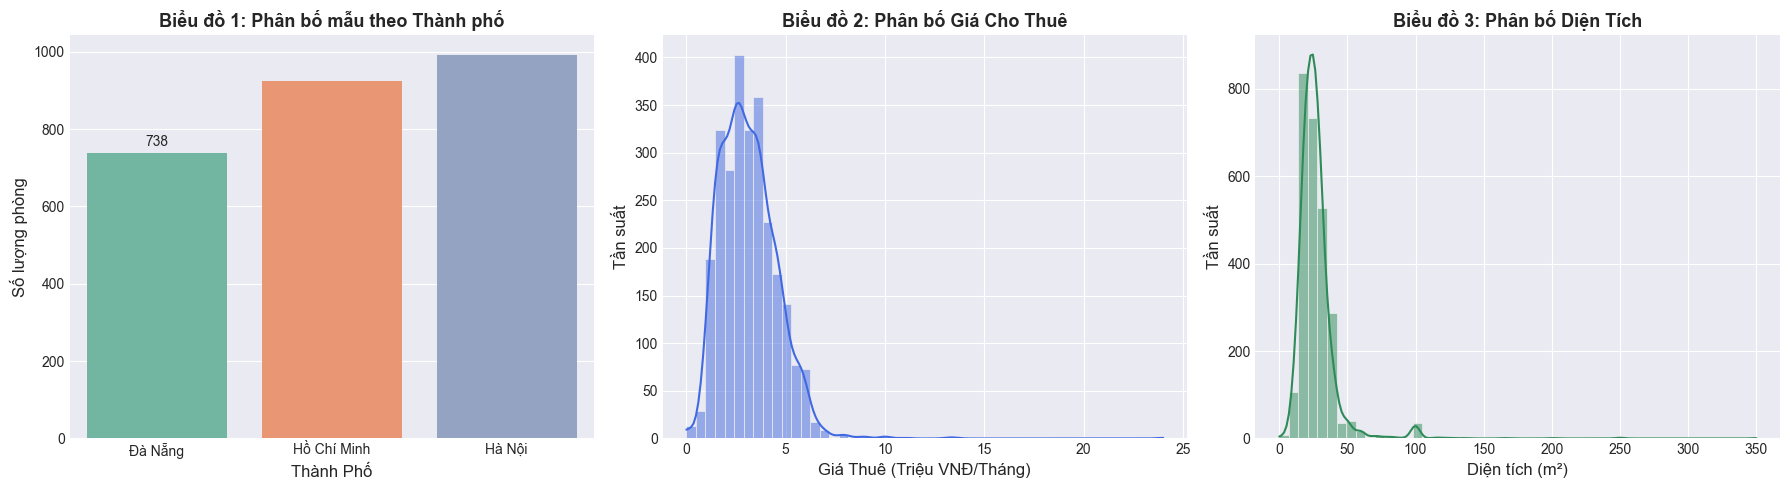

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập phong cách biểu đồ
plt.rcParams['font.family'] = 'sans-serif'
plt.style.use('seaborn-v0_8-darkgrid')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Figure 1: Số lượng phòng trọ theo thành phố
sns.countplot(x='Thành_Phố', data=df_raw, palette='Set2', ax=axes[0])
axes[0].set_title('Biểu đồ 1: Phân bố mẫu theo Thành phố', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Số lượng phòng')
axes[0].set_xlabel('Thành Phố')
axes[0].bar_label(axes[0].containers[0], padding=3) # Hiển thị số lượng cụ thể trên đỉnh cột

# Biểu đồ 2: Phân bố Giá cho thuê (Histogram + KDE)
sns.histplot(df_raw['Giá_Cho_Thuê'], bins=50, kde=True, color='royalblue', ax=axes[1])
axes[1].set_title('Biểu đồ 2: Phân bố Giá Cho Thuê', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Giá Thuê (Triệu VNĐ/Tháng)')
axes[1].set_ylabel('Tần suất')

# Biểu đồ 3: Phân bố Diện tích (Histogram + KDE)
sns.histplot(df_raw['Diện_Tích_m2'], bins=50, kde=True, color='seagreen', ax=axes[2])
axes[2].set_title('Biểu đồ 3: Phân bố Diện Tích', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Diện tích (m²)')
axes[2].set_ylabel('Tần suất')

plt.tight_layout()
plt.show()

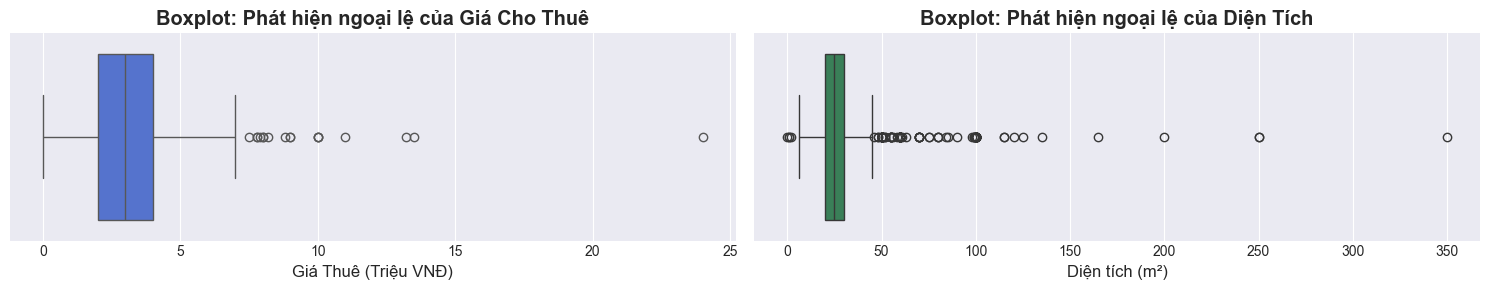

In [11]:
# Khởi tạo khung vẽ gồm 2 biểu đồ Boxplot
fig, axes = plt.subplots(1, 2, figsize=(15, 3))

# Boxplot cho Giá cho thuê
sns.boxplot(x=df_raw['Giá_Cho_Thuê'], color='royalblue', ax=axes[0])
axes[0].set_title('Boxplot: Phát hiện ngoại lệ của Giá Cho Thuê', fontweight='bold')
axes[0].set_xlabel('Giá Thuê (Triệu VNĐ)')

# Boxplot cho Diện tích
sns.boxplot(x=df_raw['Diện_Tích_m2'], color='seagreen', ax=axes[1])
axes[1].set_title('Boxplot: Phát hiện ngoại lệ của Diện Tích', fontweight='bold')
axes[1].set_xlabel('Diện tích (m²)')

plt.tight_layout()
plt.show()

**Nhận xét từ biểu đồ phân tích đơn biến:**

1. **Về phân bổ khu vực (Biểu đồ 1):** Số lượng mẫu thu thập được phân bổ tương đối đồng đều ở các thành phố lớn (Hà Nội, TP.HCM, Đà Nẵng), đảm bảo tính đại diện cho mặt bằng chung của thị trường phòng trọ sinh viên.
2. **Về phân bố hình dáng (Biểu đồ 2 & 3):** - Cả hai biến `Giá_Cho_Thuê` và `Diện_Tích_m2` đều **không tuân theo phân phối chuẩn (Normal Distribution)**. Đường cong KDE cho thấy dữ liệu bị **lệch phải (Right-skewed)** rất nặng.
   - Nguyên nhân: Phần lớn phòng trọ sinh viên tập trung ở phân khúc giá rẻ (2 - 5 triệu) và diện tích nhỏ (15 - 30 m²). Tuy nhiên, có một số lượng nhỏ các căn hộ dịch vụ cao cấp hoặc nhà nguyên căn có giá và diện tích kéo dài chiếc "đuôi" của đồ thị về phía bên phải.
3. **Về Ngoại lệ / Outliers:**
   - Biểu đồ Boxplot xuất hiện rất nhiều các điểm đen (outliers) nằm ngoài râu (whiskers) của đồ thị. 
   - Tồn tại các điểm dữ liệu bất hợp lý như: Giá thuê = 0 đồng, hoặc Diện tích lên tới 350 m². Những dữ liệu rác này nếu đưa thẳng vào mô hình Hồi quy (Regression) sẽ làm giảm độ chính xác và gây ra hiện tượng thiên kiến.